# Breast Cancer (UCI Original) — Shared Loader & Helpers

This section sets up **shared utilities** to reuse across all model scripts:
- Load the **UCI Breast Cancer Wisconsin (Original)** dataset **directly from the source**.
- Clean and prepare the data.
- Provide a **stratified train/test split** (75/25).

## Dataset Source (UCI – Original)

We will use the original dataset hosted by UCI:

- URL: `https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original)`  
- Direct data file: `breast-cancer-wisconsin.data`

**Columns (per UCI):**
1. `sample_code_number` *(ID — will be dropped)*  
2. `clump_thickness`  
3. `uniformity_cell_size`  
4. `uniformity_cell_shape`  
5. `marginal_adhesion`  
6. `single_epithelial_cell_size`  
7. `bare_nuclei` *(contains missing values encoded as '?')*  
8. `bland_chromatin`  
9. `normal_nucleoli`  
10. `mitoses`  
11. `class` *(2 = benign, 4 = malignant)*

**Target mapping for classifiers:**  
- `2 → 0` (benign)  
- `4 → 1` (malignant)


## Preprocessing Plan

1. **Load** the raw CSV directly from the UCI URL (no local file).  
2. **Handle missing values**: Replace `'?'` with `NaN` and drop rows with missing values (only affects `bare_nuclei`).  
3. **Drop ID**: Remove `sample_code_number`.  
4. **Map labels**: `class` values `2→0` (benign) and `4→1` (malignant).  
5. **Return features/labels** as `X, y`.  
6. **Split** with `train_test_split` using `test_size=0.25`, `random_state=42`, and `stratify=y`.


In [1]:
# Imports & constants
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

COLS = [
    "sample_code_number",            # ID (drop)
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"                          # 2=benign, 4=malignant
]


## `load_clean_data()`

- Reads from the UCI URL.  
- Replaces `'?'` with `NaN` (in `bare_nuclei`).  
- Drops rows with missing values.  
- Drops the ID column.  
- Maps `class` from `{2:0, 4:1}`.  
- Returns `X, y`.


In [2]:
def load_clean_data():
    # Read directly from UCI (no local CSV)
    df = pd.read_csv(UCI_URL, header=None, names=COLS)
    # Handle missing values marked as "?"
    df = df.replace("?", pd.NA)
    df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors="coerce")
    df = df.dropna().copy()

    # Drop ID column
    df = df.drop(columns=["sample_code_number"])

    # Map class: 2 -> 0 (benign), 4 -> 1 (malignant)
    df["class"] = df["class"].map({2: 0, 4: 1})

    X = df.drop(columns=["class"])
    y = df["class"].astype(int)
    return X, y


## `get_data_splits(test_size=0.25, random_state=42)`

- Returns a stratified 75/25 train/test split.  
- Keeps results reproducible via `random_state`.


In [3]:
def get_data_splits(test_size=0.25, random_state=42):
    X, y = load_clean_data()
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


## `evaluate_and_log(model_name, y_true, y_pred, results_dir="results")`

Logs metrics for compiling the **Word table later**:

- Appends one row per model to `results/metrics.csv` with: `model`, `accuracy`.  
- Appends one row per model to `results/confusion_matrices.csv` with: `model`, `tn`, `fp`, `fn`, `tp`.  
- Prints summary to the console.


In [4]:
def evaluate_and_log(model_name, y_true, y_pred, results_dir="results"):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP], [FN, TP]]

    os.makedirs(results_dir, exist_ok=True)

    # Append metrics row
    metrics_path = os.path.join(results_dir, "metrics.csv")
    mrow = pd.DataFrame([{
        "model": model_name,
        "accuracy": acc
    }])
    if os.path.exists(metrics_path):
        mrow.to_csv(metrics_path, mode="a", header=False, index=False)
    else:
        mrow.to_csv(metrics_path, index=False)

    # Append confusion matrix row as a flat record
    cm_path = os.path.join(results_dir, "confusion_matrices.csv")
    cmrow = pd.DataFrame([{
        "model": model_name,
        "tn": int(cm[0,0]),
        "fp": int(cm[0,1]),
        "fn": int(cm[1,0]),
        "tp": int(cm[1,1]),
    }])
    if os.path.exists(cm_path):
        cmrow.to_csv(cm_path, mode="a", header=False, index=False)
    else:
        cmrow.to_csv(cm_path, index=False)

    print(f"{model_name} | Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)


## Preview the Cleaned Dataset

Let’s load the data and inspect the first few rows to confirm:
- Missing values are gone  
- `sample_code_number` is dropped  
- `class` is mapped to `0` (benign) and `1` (malignant)


In [5]:
# Preview cleaned data
X, y = load_clean_data()
print("Features shape:", X.shape)
print("Labels distribution:\n", y.value_counts())

# Show first 5 rows
pd.concat([X, y], axis=1).head()


Features shape: (683, 9)
Labels distribution:
 class
0    444
1    239
Name: count, dtype: int64


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0


## Sanity check: class balance after split
Confirm stratification worked and the test size is 25%.


In [6]:
X_train, X_test, y_train, y_test = get_data_splits()
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test  label distribution:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (512, 9)  Test shape: (171, 9)
Train label distribution:
 class
0    0.65
1    0.35
Name: proportion, dtype: float64
Test  label distribution:
 class
0    0.649
1    0.351
Name: proportion, dtype: float64


## Model — Linear SVM (kernel = linear)

Support Vector Machine with a **linear kernel**.  
We’ll scale features and enable probability estimates so we can plot ROC/PR and calibration:

- `SVC(kernel="linear", probability=True, random_state=42)`
- `StandardScaler` in a pipeline
- Same 25% test split for apples-to-apples comparison


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1) data
X_train, X_test, y_train, y_test = get_data_splits()

# 2) pipeline: scale -> linear SVM (with probs)
svm_lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", probability=True, random_state=42))
])

# 3) fit & predict
svm_lin_pipe.fit(X_train, y_train)
y_pred_svm_lin = svm_lin_pipe.predict(X_test)

# 4) log basic results (accuracy + confusion matrix to results/)
evaluate_and_log("Linear SVM (linear)", y_test, y_pred_svm_lin)


Linear SVM (linear) | Accuracy: 0.9591
Confusion Matrix:
[[106   5]
 [  2  58]]


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve


In [10]:
# probabilities
if hasattr(svm_lin_pipe, "predict_proba"):
    y_proba_svm_lin = svm_lin_pipe.predict_proba(X_test)[:, 1]
else:
    # fallback (shouldn't be needed with probability=True)
    from sklearn.preprocessing import MinMaxScaler
    y_proba_svm_lin = MinMaxScaler().fit_transform(
        svm_lin_pipe.decision_function(X_test).reshape(-1, 1)
    ).ravel()

# predictions and confusion
cm = confusion_matrix(y_test, y_pred_svm_lin)
tn, fp, fn, tp = cm.ravel()

# metrics
acc  = accuracy_score(y_test, y_pred_svm_lin)
prec = precision_score(y_test, y_pred_svm_lin, zero_division=0)
rec  = recall_score(y_test, y_pred_svm_lin, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) else np.nan
f1   = f1_score(y_test, y_pred_svm_lin, zero_division=0)

# curves
fpr, tpr, _ = roc_curve(y_test, y_proba_svm_lin)
roc_auc     = roc_auc_score(y_test, y_proba_svm_lin)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_svm_lin)
ap          = average_precision_score(y_test, y_proba_svm_lin)

# calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba_svm_lin, n_bins=10, strategy="uniform")


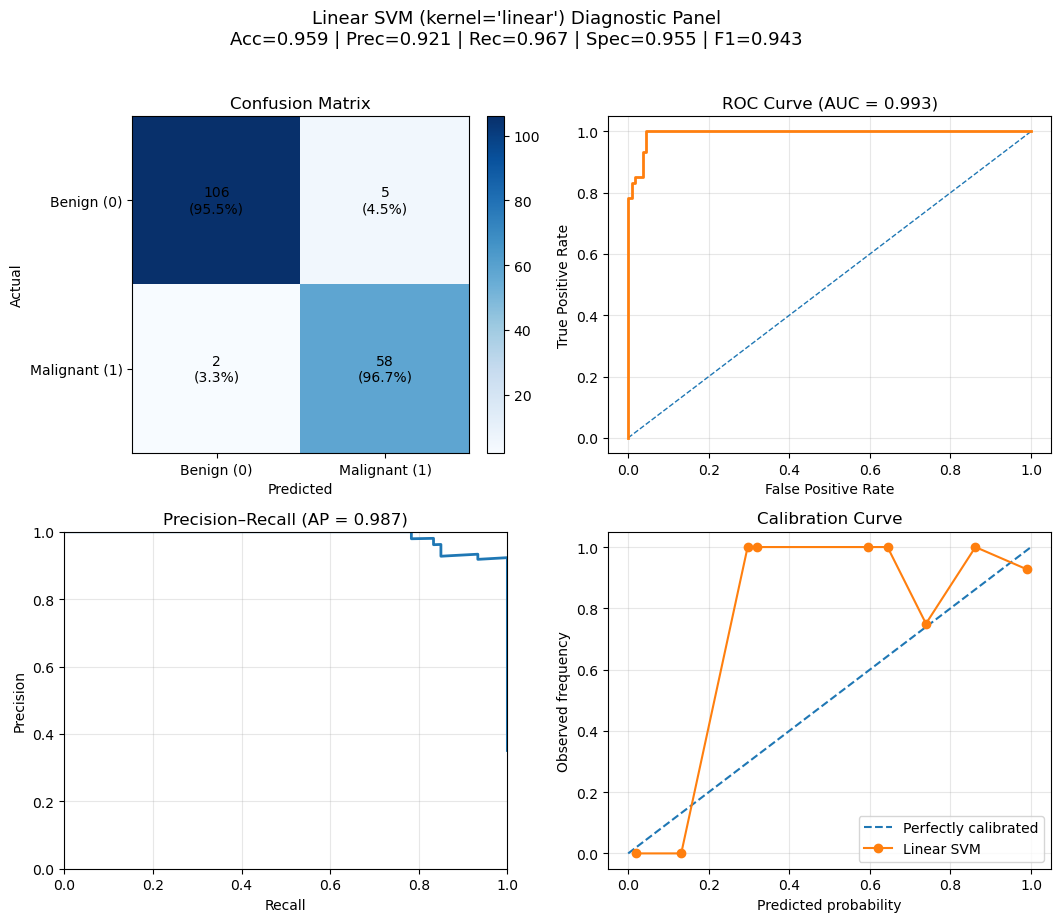

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
(ax_cm, ax_roc), (ax_pr, ax_cal) = axes

# Confusion matrix
im = ax_cm.imshow(cm, cmap="Blues")
ax_cm.set_title("Confusion Matrix")
ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(["Benign (0)","Malignant (1)"])
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(["Benign (0)","Malignant (1)"])
for (i, j), val in np.ndenumerate(cm):
    row_total = cm[i].sum()
    pct = (val / row_total * 100) if row_total else 0
    ax_cm.text(j, i, f"{val}\n({pct:.1f}%)", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

# ROC
ax_roc.plot([0,1],[0,1], linestyle="--", linewidth=1)
ax_roc.plot(fpr, tpr, linewidth=2)
ax_roc.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.grid(alpha=0.3)

# Precision–Recall
ax_pr.plot(rec_curve, prec_curve, linewidth=2)
ax_pr.set_title(f"Precision–Recall (AP = {ap:.3f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1)
ax_pr.grid(alpha=0.3)

# Calibration
ax_cal.plot([0,1],[0,1], linestyle="--", label="Perfectly calibrated")
ax_cal.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label="Linear SVM")
ax_cal.set_title("Calibration Curve")
ax_cal.set_xlabel("Predicted probability"); ax_cal.set_ylabel("Observed frequency")
ax_cal.legend(); ax_cal.grid(alpha=0.3)

fig.suptitle(
    f"Linear SVM (kernel='linear') Diagnostic Panel\n"
    f"Acc={acc:.3f} | Prec={prec:.3f} | Rec={rec:.3f} | Spec={spec:.3f} | F1={f1:.3f}",
    y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()


### Linear SVM (kernel = linear) — Model Performance Summary

**Key Metrics:**
- **Accuracy:** 95.9%  
- **Precision:** 92.1% — High proportion of correct malignant predictions.  
- **Recall (Sensitivity):** 96.7% — Missed only 2 malignant cases.  
- **Specificity:** 95.5% — Correctly classified most benign cases.  
- **F1 Score:** 94.3% — Balanced strength in both precision and recall.  
- **ROC AUC:** 0.993 — Excellent class separation.  
- **PR AUC:** 0.987 — Maintains strong precision even at high recall.

**Confusion Matrix:**
- **True Negatives (TN):** 106  
- **False Positives (FP):** 5  
- **False Negatives (FN):** 2  
- **True Positives (TP):** 58  

**Interpretation:**  
This Linear SVM matches Logistic Regression’s performance, reinforcing that the dataset is highly separable in a linear space. Its recall is critical for catching malignant cases with minimal misses, while keeping false positives low. The near-perfect ROC and PR curves confirm robust discrimination and reliability of predictions.
